# Demonstartor System Model 1
## Electronic Filter System

### Description

The electronic filter system is a simple example of an electronic circuit that consists of a voltage source that generates a noisy sinusoidal signal.
This signal is then passed through two low-pass filters and a band-pass filter to remove high-frequency noise and unwanted frequency components.

<img src="./img/ElectronicFilterSysetmCircuit.png" alt="Filter System" width="800"/>


Change path to access `SysSimX` module

In [6]:
import os
import sys
from pathlib import Path
repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))

Import functionality to create equation-based system model

In [7]:
from SysSimX.core.units import _ureg
from SysSimX.core.physical_value import PhysicalValue

from SysSimX.equationbased.package import Package
from SysSimX.equationbased.model import Model
from SysSimX.equationbased.interfaces import RealInput, RealOutput
from SysSimX.equationbased.variable import Variable
from SysSimX.equationbased.component import Instance
from SysSimX.equationbased.equation import Equation, Connect
from SysSimX.equationbased.utilities import der, sin, pi, time

Define the hierachy of the system model:

```
FilterSystem/                     (top-level package)
├─ package.mo
├─ package.order
├─ demo.mo                        (top-level demo)
├─ VoltageSource.mo               (subsystem)
├─ LowPassRC.mo                   (subsystem)
├─ BandPassRLC.mo                 (subsystem)                           
```

In [8]:
# Print current working directory
print(f"Current working directory: {Path.cwd()}")
!rm -rf FilterSystem

Current working directory: /home/flo/repos/SystemSimulation/demos/FilterSystem


Create the packages for the system model:

In [9]:
system_package_name = "FilterSystem"
system_path = Path.cwd() / system_package_name
system_package = Package(name=system_package_name, path=system_path)

/home/flo/repos/SystemSimulation/demos/FilterSystem/FilterSystem/package.mo created.


1. Create signal source model

In [10]:
# Instantiate the Model class
src = Model("SignalSource", within=system_package.name)

# Add outputs
src_uin = RealOutput("U_in", "V")
src.add_output(src_uin)

# Define parameters
src_A1 = Variable("A1", "Real", "V", 60)
src_A2 = Variable("A2", "Real", "V", 5)
src_f1 = Variable("f1", "Real", "Hz", 0.159)
src_f2 = Variable("f2", "Real", "Hz", 7.96)

# Add parameters to the model
parameters = [src_A1, src_A2, src_f1, src_f2]
for param in parameters:
    src.add_parameter(param)

# Define internal variables
src_signal1 = Variable("s1", "Real", "V")
src_signal2 = Variable("s2", "Real", "V")
src.add_variable(src_signal1)
src.add_variable(src_signal2)

# Define equations
src_eqn1_lhs = src_signal1
src_eqn1_rhs = src_A1 * sin(2 * pi * src_f1 * time)
src_eqn1 = Equation(src_eqn1_lhs, src_eqn1_rhs)
src.add_equation(src_eqn1)

src_eqn2_lhs = src_signal2
src_eqn2_rhs = src_A2 * sin(2 * pi * src_f2 * time)
src_eqn2 = Equation(src_eqn2_lhs, src_eqn2_rhs)
src.add_equation(src_eqn2)

src_eqn3_lhs = src_uin
src_eqn3_rhs = src_signal1 + src_signal2
src_eqn3 = Equation(src_eqn3_lhs, src_eqn3_rhs)
src.add_equation(src_eqn3)

src.build()
print(src.modelica_code)

Model saved to FilterSystem/SignalSource.mo
within FilterSystem;
model SignalSource
  Modelica.Blocks.Interfaces.RealOutput U_in(unit="V");
  parameter Real A1(unit="V") = 60;
  parameter Real A2(unit="V") = 5;
  parameter Real f1(unit="Hz") = 0.159;
  parameter Real f2(unit="Hz") = 7.96;
  Real s1(unit="V");
  Real s2(unit="V");
equation
  s1 = (A1 * sin((((2.0 * 3.141592653589793) * f1) * time)));
  s2 = (A2 * sin((((2.0 * 3.141592653589793) * f2) * time)));
  U_in = (s1 + s2);
end SignalSource;


2. Create Low-Pass Filter model

In [11]:
# Instantiate the Model class
low_pass_filter = Model("LowPassFilter")

# Define the package
low_pass_filter.within = system_package.name

# Add inputs
U_in = RealInput("U_in", "V")
low_pass_filter.add_input(U_in)

# Add outputs
U_out = RealOutput("U_out", "V")
low_pass_filter.add_output(U_out)

# Define parameters
param_R = Variable("R", "Real", "Ohm", 1000)
param_C = Variable("C", "Real", "F", 1e-3)
param_U0 = Variable("U0", "Real", "V", 0)

# Add parameters to the model
parameters = [param_R, param_C, param_U0]
for param in parameters:
    low_pass_filter.add_parameter(param)

# Define initial equation
eqn_init_lhs = U_out
eqn_init_rhs = param_U0
eqn_init = Equation(eqn_init_lhs, eqn_init_rhs)
low_pass_filter.add_initial_equation(eqn_init)

# Define equations
src_eqn1_lhs = der(U_out)
src_eqn1_rhs = (U_in - U_out) / (param_R * param_C)
src_eqn1 = Equation(src_eqn1_lhs, src_eqn1_rhs)
low_pass_filter.add_equation(src_eqn1)

low_pass_filter.build()
print(low_pass_filter.modelica_code)

Model saved to FilterSystem/LowPassFilter.mo
within FilterSystem;
model LowPassFilter
  Modelica.Blocks.Interfaces.RealInput U_in(unit="V");
  Modelica.Blocks.Interfaces.RealOutput U_out(unit="V");
  parameter Real R(unit="Ohm") = 1000;
  parameter Real C(unit="F") = 0.001;
  parameter Real U0(unit="V") = 0;
initial equation
  U_out = U0;
equation
  der(U_out) = ((U_in - U_out) / (R * C));
end LowPassFilter;


3. Create Band-Pass Filter model

In [12]:
# Instantiate the Model class
band_pass_filter = Model("BandPassFilter")

# Define the package
band_pass_filter.within = system_package.name

# Add inputs
U_in = RealInput("U_in", "V")
band_pass_filter.add_input(U_in)

# Add outputs
I = RealOutput("I", "A")
IL = RealOutput("IL", "A")
band_pass_filter.add_output(I)
band_pass_filter.add_output(IL)

# Define parameters
param_R = Variable("R", "Real", "Ohm", 100)
param_C = Variable("C", "Real", "F", 1e-3)
param_L = Variable("L", "Real", "H", 1)
param_IL0 = Variable("IL0", "Real", "A", 0)
# Add parameters to the model
parameters = [param_R, param_C, param_L, param_IL0]
for param in parameters:
    band_pass_filter.add_parameter(param)

# Internal variable
internal_I_R = Variable("I_R", "Real", "A")
internal_I_C = Variable("I_C", "Real", "A")
band_pass_filter.add_variable(internal_I_R)
band_pass_filter.add_variable(internal_I_C)

# Define initial equation
eqn_init_lhs = IL
eqn_init_rhs = param_IL0
eqn_init = Equation(eqn_init_lhs, eqn_init_rhs)
band_pass_filter.add_initial_equation(eqn_init)

# Define equations
src_eqn1_lhs = internal_I_R
src_eqn1_rhs = U_in / param_R
src_eqn1 = Equation(src_eqn1_lhs, src_eqn1_rhs)
band_pass_filter.add_equation(src_eqn1)

src_eqn2_lhs = internal_I_C
src_eqn2_rhs = param_C *  der(U_in)
src_eqn2 = Equation(src_eqn2_lhs, src_eqn2_rhs)
band_pass_filter.add_equation(src_eqn2)

src_eqn3_lhs = der(IL)
src_eqn3_rhs = U_in / param_L
src_eqn3 = Equation(src_eqn3_lhs, src_eqn3_rhs)
band_pass_filter.add_equation(src_eqn3)

eqn4_lhs = I
eqn4_rhs = internal_I_R + internal_I_C + IL
eqn4 = Equation(eqn4_lhs, eqn4_rhs)
band_pass_filter.add_equation(eqn4)

band_pass_filter.build()
print(band_pass_filter.modelica_code)

Model saved to FilterSystem/BandPassFilter.mo
within FilterSystem;
model BandPassFilter
  Modelica.Blocks.Interfaces.RealInput U_in(unit="V");
  Modelica.Blocks.Interfaces.RealOutput I(unit="A");
  Modelica.Blocks.Interfaces.RealOutput IL(unit="A");
  parameter Real R(unit="Ohm") = 100;
  parameter Real C(unit="F") = 0.001;
  parameter Real L(unit="H") = 1;
  parameter Real IL0(unit="A") = 0;
  Real I_R(unit="A");
  Real I_C(unit="A");
initial equation
  IL = IL0;
equation
  I_R = (U_in / R);
  I_C = (C * der(U_in));
  der(IL) = (U_in / L);
  I = ((I_R + I_C) + IL);
end BandPassFilter;


4. Create demo model to connect components

In [13]:
# Create demo model to connect components
demo_model = Model("DemoModel")
demo_model.within = system_package.name

# Add components to the model
type_src = src.within + "." + src.name
src_config = "A1=60, A2=5, f1=0.159, f2=7.96"
SRC = Instance(type_src, "src", src_config)
demo_model.add_instance(SRC)

type_lpf = low_pass_filter.within + "." + low_pass_filter.name
lpf_config = "R=1000, C=1e-03, U0=0"
LPF1 = Instance(type_lpf, "lpf1", lpf_config)
LPF2 = Instance(type_lpf, "lpf2", lpf_config)
demo_model.add_instance(LPF1)
demo_model.add_instance(LPF2)

type_bpf = band_pass_filter.within + "." + band_pass_filter.name
bpf_config = "R=1.26, C=0.0253, L=1, IL0=0"
BPF = Instance(type_bpf, "bpf", bpf_config)
demo_model.add_instance(BPF)

# Add variables for outputs
src_voltage = Variable("src_voltage", "Real", "V"); demo_model.add_variable(src_voltage)
lpf1_voltage = Variable("lpf1_voltage", "Real", "V"); demo_model.add_variable(lpf1_voltage)
lpf2_voltage = Variable("lpf2_voltage", "Real", "V"); demo_model.add_variable(lpf2_voltage)
bpf_current = Variable("bpf_current", "Real", "A"); demo_model.add_variable(bpf_current)
bpf_IL = Variable("bpf_IL", "Real", "A"); demo_model.add_variable(bpf_IL)

# Define connecting equations
demo_model.connect(SRC.U_in, LPF1.U_in) # connect(src.U_in, lpf1.U_in);
demo_model.connect(LPF1.U_out, LPF2.U_in)
demo_model.connect(LPF2.U_out, BPF.U_in)

# Equation for output monitoring
src_eqn1 = Equation(src_voltage, SRC.U_in) # Equation: src_voltage = src.U_in
demo_model.add_equation(src_eqn1)
src_eqn2 = Equation(lpf1_voltage, LPF1.U_out)
demo_model.add_equation(src_eqn2)
src_eqn3 = Equation(lpf2_voltage, LPF2.U_out)
demo_model.add_equation(src_eqn3)
eqn4 = Equation(bpf_current, BPF.I)
demo_model.add_equation(eqn4)
eqn5 = Equation(bpf_IL, BPF.IL)
demo_model.add_equation(eqn5)


demo_model.build()
print(demo_model.modelica_code)

Model saved to FilterSystem/DemoModel.mo
within FilterSystem;
model DemoModel
  Real src_voltage(unit="V");
  Real lpf1_voltage(unit="V");
  Real lpf2_voltage(unit="V");
  Real bpf_current(unit="A");
  Real bpf_IL(unit="A");
  FilterSystem.SignalSource src(A1=60, A2=5, f1=0.159, f2=7.96);
  FilterSystem.LowPassFilter lpf1(R=1000, C=1e-03, U0=0);
  FilterSystem.LowPassFilter lpf2(R=1000, C=1e-03, U0=0);
  FilterSystem.BandPassFilter bpf(R=1.26, C=0.0253, L=1, IL0=0);
equation
  connect(src.U_in, lpf1.U_in);
  connect(lpf1.U_out, lpf2.U_in);
  connect(lpf2.U_out, bpf.U_in);
  src_voltage = src.U_in;
  lpf1_voltage = lpf1.U_out;
  lpf2_voltage = lpf2.U_out;
  bpf_current = bpf.I;
  bpf_IL = bpf.IL;
end DemoModel;


In [14]:
from OMPython import ModelicaSystem

file_name = os.path.join(system_package.path, "package.mo")
model_name = system_package.name + "." + demo_model.name

mo_model = ModelicaSystem(file_name, model_name)


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.



In [15]:
# Build the model
print("Building model...")
mo_model.buildModel()
print("Model built successfully")

Building model...

Model built successfully


In [16]:
# Get model information
print("Model Information:")
print("-" * 30)

outputs = mo_model.getOutputs()
inputs = mo_model.getInputs()
parameters = mo_model.getParameters()
continuous = mo_model.getContinuous()

print(f"Outputs:    {outputs}")
print(f"Inputs:     {inputs}")
print(f"Parameters: {parameters}")
print(f"Continuous: {continuous}")

Model Information:
------------------------------
Outputs:    {}
Inputs:     {}
Parameters: {'bpf.C': '0.0253', 'bpf.IL0': '0.0', 'bpf.L': '1.0', 'bpf.R': '1.26', 'lpf1.C': '0.001', 'lpf1.R': '1000.0', 'lpf1.U0': '0.0', 'lpf2.C': '0.001', 'lpf2.R': '1000.0', 'lpf2.U0': '0.0', 'src.A1': '60.0', 'src.A2': '5.0', 'src.f1': '0.159', 'src.f2': '7.96'}
Continuous: {'bpf.IL': None, 'lpf1.U_out': None, 'lpf2.U_out': None, 'der(bpf.IL)': None, 'der(lpf1.U_out)': None, 'der(lpf2.U_out)': None, '$cse1': None, '$cse2': None, 'bpf.I_C': None, 'bpf.I_R': None, 'bpf_current': None, 'src.s1': None, 'src.s2': None, 'src_voltage': None, 'bpf.I': None, 'bpf.U_in': None, 'bpf_IL': None, 'lpf1.U_in': None, 'lpf1_voltage': None, 'lpf2.U_in': None, 'lpf2_voltage': None, 'src.U_in': None}


In [17]:
# Set simulation parameters
simulation_options = [
    "startTime=0.0",
    "stopTime=10.0",        
    "stepSize=0.01",
    "tolerance=1e-6"
]

mo_model.setSimulationOptions(simulation_options)
current_options = mo_model.getSimulationOptions()
print(f"Simulation options: {current_options}")

Simulation options: {'startTime': '0.0', 'stopTime': '10.0', 'stepSize': '0.01', 'tolerance': '1e-6', 'solver': 'dassl', 'outputFormat': 'mat'}


In [18]:
# Run simulation
print("Running simulation...")
mo_model.simulate()
print("Simulation completed successfully")

Running simulation...
LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.
Simulation completed successfully


In [19]:
print("Extracting results...")

time_vals, src_voltage = mo_model.getSolutions(["time", "src_voltage"])
_, lpf1_voltage = mo_model.getSolutions(["time", "lpf1_voltage"])
_, lpf2_voltage = mo_model.getSolutions(["time", "lpf2_voltage"])
_, bpf_current = mo_model.getSolutions(["time", "bpf_current"])
_, bpf_inductor_current = mo_model.getSolutions(["time", "bpf_IL"])

print(f"Results extracted: {len(time_vals)} time points")
print(f"Time range: {time_vals[0]:.3f} to {time_vals[-1]:.3f} seconds")
print(f"Time step: {(time_vals[-1] - time_vals[0]) / (len(time_vals) - 1):.4f} seconds")

Extracting results...
Results extracted: 1002 time points
Time range: 0.000 to 10.000 seconds
Time step: 0.0100 seconds


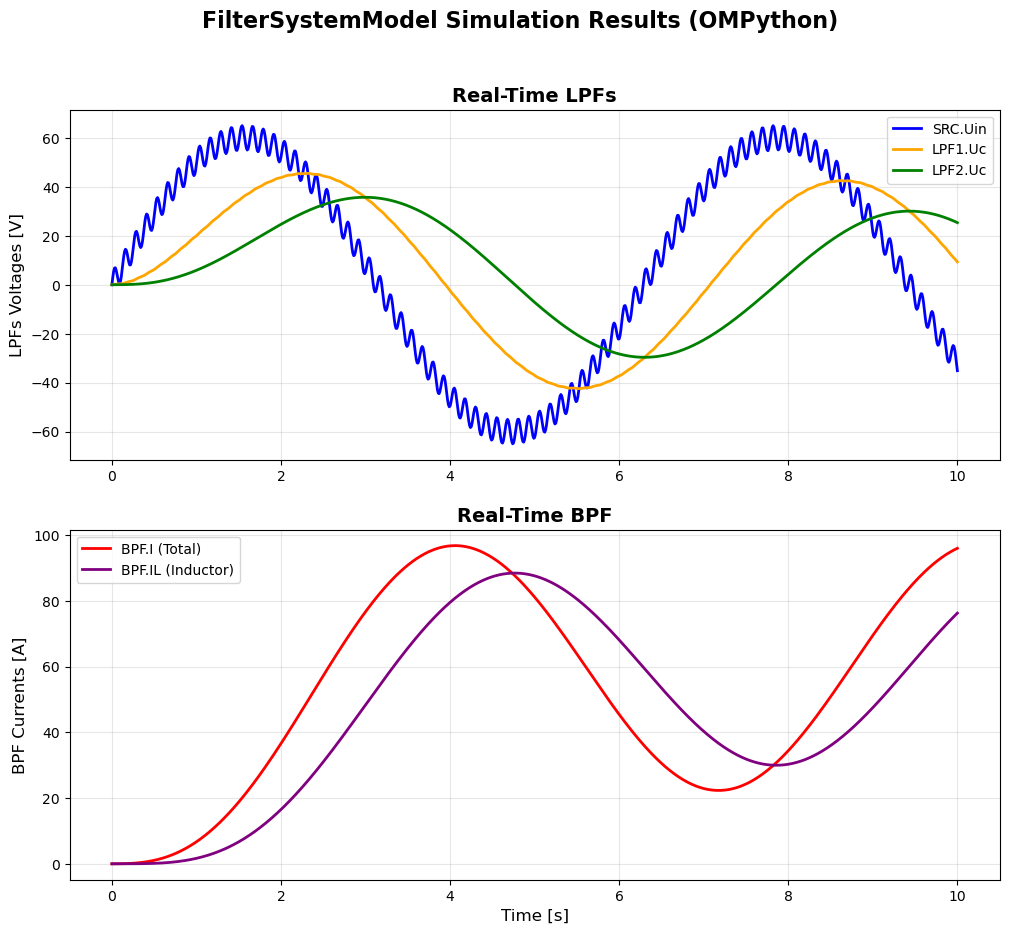

In [20]:
import matplotlib.pyplot as plt

# Create plots matching the Python plot_config groups
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Group 1: Real-Time LPFs (voltages)
ax1.plot(time_vals, src_voltage, label='SRC.Uin', linewidth=2, color='blue')
ax1.plot(time_vals, lpf1_voltage, label='LPF1.Uc', linewidth=2, color='orange')
ax1.plot(time_vals, lpf2_voltage, label='LPF2.Uc', linewidth=2, color='green')

ax1.set_title("Real-Time LPFs", fontsize=14, fontweight='bold')
ax1.set_ylabel("LPFs Voltages [V]", fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Group 2: Real-Time BPF (currents)  
ax2.plot(time_vals, bpf_current, label='BPF.I (Total)', linewidth=2, color='red')
ax2.plot(time_vals, bpf_inductor_current, label='BPF.IL (Inductor)', linewidth=2, color='purple')

ax2.set_title("Real-Time BPF", fontsize=14, fontweight='bold')
ax2.set_ylabel("BPF Currents [A]", fontsize=12)
ax2.set_xlabel("Time [s]", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle("FilterSystemModel Simulation Results (OMPython)", 
            fontsize=16, fontweight='bold', y=0.98)

plt.show()